In [1]:
import pandas as pd
import numpy as np
import os
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"]="platform"


from pathlib import Path
import pickle
import time
from itertools import product

#### graphical
import matplotlib.pyplot as plt
import corner


import numpyro, os, json
import numpyro.distributions as dist
import jax.numpy as jnp
from numpyro.infer import Predictive
import arviz as az
import jax

from numpyro import handlers
from numpyro.infer import MCMC, NUTS, Predictive

from emulator import Emulator
from utils import norm, unnorm 

from numpyro.handlers import reparam
from numpyro.infer.reparam import LocScaleReparam

from jax import vmap, Array
from WMSE import WMSE, WMSE_metric

import tensorflow as tf
os.environ["CUDA_VISIBLE_DEVICES"]="1"
jax.config.update('jax_enable_x64', True)
numpyro.enable_x64()

colors = ['#ee6a4d', '#e9909b', '#8cbeb3', '#FFD97D', '#E0F6D8']

physical_devices = tf.config.list_physical_devices("GPU") 

tf.config.experimental.set_memory_growth(physical_devices[0], True)

2025-08-27 16:15:19.047343: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756307719.058425 1535470 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756307719.061871 1535470 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
def sample_beta(param_name, loc, scale, alpha = 2, beta = 2):

    beta_samp = numpyro.sample(f'{param_name}_beta', dist.Beta(alpha, beta))

    return numpyro.deterministic(param_name, loc + scale*beta_samp)

In [3]:
from jax.lib import xla_bridge
print(xla_bridge.get_backend().platform)
jax.process_index(backend=None)

/tmp/ipykernel_1535470/4047632791.py:2: DeprecationWarning: jax.lib.xla_bridge.get_backend is deprecated; use jax.extend.backend.get_backend.
  print(xla_bridge.get_backend().platform)


cpu


0

In [4]:
seed = 42

df_full = pd.read_hdf('../grids/Chiara.hdf5', key='df') ## edit for your grid!!

df_full['logLPhot'] = np.log10(df_full['LPhot'])

df_full['lognumax'] = np.log10(df_full['numax']*3090)

df_full['logdnuSer'] = np.log10(df_full['dnuSer']*135)

df_full['logAge'] = np.log10(df_full['age'])

#### define inputs
inputs = ['massini', 'zini', 'yini', 'alphaMLT', 'logAge', 'eta', 'alphaFe']

#### define outputs
classical_outputs = ['FeH', 'logLPhot', 'Teff']
astero_outputs = ['lognumax', 'logdnuSer'] 

outputs = classical_outputs+astero_outputs

df = df_full[inputs+outputs]

df_norm = (df - df.min())/(df.max() - df.min())
df_train = df.sample(frac=0.95, random_state=seed)
df_test = df.drop(df_train.index)
df_small = df_full.sample(1000)

In [5]:
normconsts = np.load('../grids/Chiara-normconsts-logAge.npy', allow_pickle = True).item()

modelpath = '/home/hatte/M4/models'

n_dense_layers = 6

dense_layer_units = 128

#Nepochs = 5000

Nepochs = 100000

learning_rate = 0.0001

model_name = 'logAge-logLPhot-lognumax-logdnufit-exponent-6e-6-Adam'

loss_func = 'WMSE'

checkpoint_dir = f'{modelpath}/long-runs/checkpoint/chk-{model_name}-nlayers-{n_dense_layers}-nunits-{dense_layer_units}-epochs-{Nepochs}-lrate-{learning_rate}-lossfunc-{loss_func}.model.keras'

emulator_kwargs =  {'model_name':model_name, 'n_dense_layers':n_dense_layers, 'dense_layer_units':dense_layer_units, 'Nepochs':Nepochs, 'lrate':learning_rate, \
        'loss':loss_func, 'model_dir':'../models',  'inputs': ['massini', 'zini', 'yini', 'alphaMLT', 'logAge', 'eta', 'alphaFe'], 'outputs':['FeH', 'logLPhot', 'Teff', 'lognumax', 'logdnuSer'],\
        'normconsts':normconsts, 'checkpoint_dir':checkpoint_dir, 'custom_objects':{'WMSE':WMSE_metric}}

model_outputs = Emulator(emulator_kwargs, normalised = False)
model= tf.keras.models.load_model(checkpoint_dir, custom_objects = {'WMSE':WMSE_metric})

I0000 00:00:1756307725.677789 1535470 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 18257 MB memory:  -> device: 0, name: NVIDIA RTX A4500, pci bus id: 0000:61:00.0, compute capability: 8.6


# For working with Maddy's Data

In [6]:
H22 = pd.read_csv('../data/Howell_2022.txt')
H22 = H22[(H22['QF'] == 'D')&(H22['ID'].str.contains('RGB'))]

numax = H22['νmax'].str.split('±', expand=True)[0].astype(float)
enumax_obs = H22['νmax'].str.split('±', expand=True)[1].astype(float)
enumax_pred = 0.009*numax

enumax = np.sqrt(enumax_obs**2 + enumax_pred**2)

dnu = H22['∆ν'].str.split('±', expand=True)[0].astype(float)
ednu_obs = H22['∆ν'].str.split('±', expand=True)[1].astype(float)
ednu_pred = 0.007*dnu

ednu = np.sqrt(ednu_obs**2 + ednu_pred**2)

LPhot = H22['L/L⊙'].str.split('±', expand=True)[0].astype(float)
eLPhot_obs = 0.5*np.sqrt(H22['L/L⊙'].str.split('±', expand=True)[1].astype(float)**2 + H22['L/L⊙'].str.split('±', expand=True)[2].astype(float)**2)
eLPhot_pred = 0.011*LPhot

eLPhot = np.sqrt(eLPhot_obs**2 + eLPhot_pred**2)


Teff = H22['Teff'].str.split('±', expand=True)[0].astype(float)
eTeff = H22['Teff'].str.split('±', expand=True)[1].astype(float)


num_stars = 1
index = 5


obs = {'FeH':-1.1,  'Teff':Teff.values[index], 'numax':numax.values[index], 'dnuSer':dnu.values[index], 'logLPhot':np.log10(LPhot.values[index])}
unc = {'Teff':eTeff.values[index], 'numax':enumax.values[index], 'dnuSer':ednu.values[index], 'FeH':0.07, 'logLPhot':eLPhot.values[index]/LPhot.values[index]*1/np.log(10)}

# For working with Yingxiang's data

In [7]:
Y25 = pd.read_csv('M4_seismicanalysis_Yingxiang_Feb25.csv')
Y25 = Y25[(Y25['Quality_flag'] == 'D')&(Y25['evol_stage'] == 'RGB')&(Y25['numax_pyMon']>12)&(Y25['Delta_nu']>0)]

IDs = Y25['star_id']

numax = Y25['numax_pyMon']
enumax_obs = Y25['numax_err_pyMon']
enumax_pred = 0.009*numax

enumax = np.sqrt(enumax_obs**2 + enumax_pred**2)

dnu = Y25['Delta_nu']
ednu_obs = 0.03*Y25['Delta_nu']
ednu_pred = 0.007*dnu
ednu_model = 0.0*Y25['Delta_nu']
ednu = np.sqrt(ednu_obs**2 + ednu_pred**2 + ednu_model**2)

LPhot = Y25['Lum_bol']
eLPhot_obs = np.sqrt(Y25['Lum_bol_err_random']**2 + Y25['Lum_bol_err_systematic']**2)
eLPhot_pred = 0.011*LPhot
eLPhot = np.sqrt(eLPhot_obs**2 + eLPhot_pred**2)

Teff = Y25['Teff_final']
eTeff = Y25['Teff_err_final']



# Tailo's data

In [6]:
T22 = pd.read_csv('../data/Tailo_2022_processed.csv')

IDs = T22['WID']

numax = T22['numax']
enumax_obs = T22['enumax']
enumax_pred = 0.009*numax
enumax = np.sqrt(enumax_obs**2 + enumax_pred**2)

dnu = T22['dnu']
ednu_obs = T22['ednu']
ednu_pred = 0.007*dnu
ednu = np.sqrt(ednu_obs**2 + ednu_pred**2)

LPhot = T22['LPhot']
eLPhot_obs = T22['eLPhot']
eLPhot_pred = 0.011*LPhot
eLPhot = np.sqrt(eLPhot_obs**2 + eLPhot_pred**2)

Teff = T22['Teff']

# Tailo cross Marino

In [82]:
T22 = pd.read_csv('../data/Tailo_2022_processed.csv')


#Think its index 4 throwing it off

IDs = T22['WID']

numax = T22['numax']
enumax_obs = T22['enumax']
enumax_pred = 0.009*numax
enumax = np.sqrt(enumax_obs**2 + enumax_pred**2)

dnu = T22['dnu']
ednu_obs = T22['ednu']
ednu_pred = 0.007*dnu
ednu = np.sqrt(ednu_obs**2 + ednu_pred**2)

LPhot = T22['LPhot']
eLPhot_obs = T22['eLPhot']
eLPhot_pred = 0.011*LPhot
eLPhot = np.sqrt(eLPhot_obs**2 + eLPhot_pred**2)

Teff = T22['Teff']

num_stars = len(Teff)

obs = {'FeH':-1.07*np.ones_like(Teff.values),  'Teff':Teff.values, 'numax':numax.values, 'dnuSer':dnu.values,'logLPhot':np.log10(LPhot.values), 'LPhot':LPhot.values}
unc = {'Teff':Teff.values, 'numax': enumax.values, 'dnuSer':ednu.values, 'FeH':0.05*np.ones_like(Teff.values), 'logLPhot':eLPhot.values/LPhot.values*1/np.log(10), 'LPhot':eLPhot.values}
unc['Teff'] = 100*np.ones_like(Teff.values)

In [12]:
T22

,LPhot,eLPhot,Teff,numax,enumax,dnu,ednu,WID,POPCUBI
0,37.865,4.083,4788.0,38.724,0.965,4.616,0.180,W491,2G
1,21.765,2.192,4926.0,75.929,2.367,7.613,0.231,W508,2G
2,71.180,7.748,4668.0,18.148,1.024,2.558,0.081,W760 ( * ),2G
3,28.142,3.030,4844.0,53.392,2.258,6.056,0.171,W779,1G
4,12.892,1.235,5030.0,123.780,3.537,11.765,0.309,W837,2G
5,21.934,2.229,4900.0,71.632,2.839,7.449,0.301,W1068,2G
6,48.529,5.227,4787.0,31.402,1.722,3.899,0.296,W1091,2G
7,28.109,3.026,4858.0,50.740,0.995,5.375,0.272,W1156,1G
8,22.325,2.271,4885.0,72.196,2.312,7.132,0.440,W1582,1G
9,20.374,2.016,4966.0,83.731,1.718,8.619,0.680,W1717,2G


In [295]:
from numpyro.handlers import reparam
from numpyro.infer.reparam import LocScaleReparam

def massfromage(age):
    logage = np.log(age)
    return np.exp(-0.3*logage + 2.4)

def lnsigmoid(x, k, mini, spread):
    s = k*(x - mini)/spread
    y = (1 + jnp.exp(-s))
    return -1*jnp.log(y)

In [341]:
lnsigmoid(0.65, 10, 0.7, 0.1)

Array(-5.00671535, dtype=float64, weak_type=True)

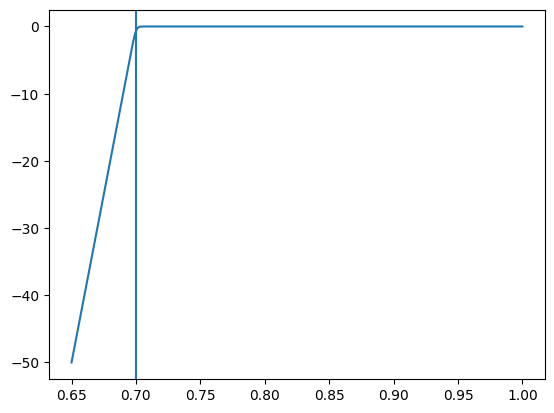

In [343]:
plt.plot(np.linspace(0.65, 1, 10000), lnsigmoid(np.linspace(0.65, 1, 10000), 10, 0.7, 0.01))
plt.axvline(0.7)

# Fit a star 

In [396]:
#@reparam(config={"alphaFe":LocScaleReparam(), "zini":LocScaleReparam()})

def star(uncs, obs = model_outputs.obs_dict):

    with numpyro.plate("star", num_stars):    

        age = numpyro.sample('age', dist.TruncatedNormal(11000, 3000, low = 100))

        tau = sample_beta('tau', 1.0, 0.5, alpha = 2, beta = 2)

        massini = numpyro.deterministic ('massini', tau*jnp.exp(-0.3*jnp.log(age) + 2.4))

        numpyro.factor('logfac',lnsigmoid(massini, 10, 0.7, 0.01))

        zini = sample_beta('zini', 0.5*0.01756*10**-1.1, 2*0.01756*10**-1.1, alpha = 2, beta = 2) #This is probably far too conservative 

        yini = sample_beta('yini', 0.23, 0.05, alpha = 2.5, beta = 5)

        alphaMLT = sample_beta('alphaMLT', 1.5, 0.8, alpha = 1.5, beta = 1.5)

        eta = sample_beta('eta', 0.0004, 0.29, alpha = 1.5, beta = 1.5)

        alphaFe = sample_beta('alphaFe', 0.31, 0.15, alpha = 5, beta = 5)
#        alphaFe = numpyro.sample('alphaFe', dist.Normal(uncs['alphaFe'], 0.05))
        #I have put this here as a custom prior on each star - really it should be in the data, but that requires retraining the network I think
               
        params = jnp.stack([massini, zini, yini, alphaMLT, jnp.log10(age), eta, alphaFe], axis = -1)

        pred = model_outputs(params)

    FeH = numpyro.sample("FeH", dist.StudentT(df = 10, loc = pred[:, 0], scale = uncs['FeH']), obs=obs['FeH'])
    
    LPhot = numpyro.sample("LPhot", dist.StudentT(df = 10, loc = 10**pred[:, 1], scale = uncs['LPhot']), obs=obs['LPhot'])
    
    Teff = numpyro.sample("Teff", dist.StudentT(df = 10, loc = pred[:, 2], scale = uncs['Teff']), obs=obs['Teff'])

 #   numax = numpyro.sample("numax", dist.StudentT(df = 4, loc = 10**(pred[:, 3]), scale = uncs['numax']), obs=obs['numax'])

    dnu = numpyro.sample("dnuSer", dist.StudentT(df = 10, loc = 10**(pred[:, 4]), scale = uncs['dnuSer']), obs=obs['dnuSer'])
 





In [397]:
T22

,LPhot,eLPhot,Teff,numax,enumax,dnu,ednu,WID,POPCUBI
0,37.865,4.083,4788.0,38.724,0.965,4.616,0.180,W491,2G
1,21.765,2.192,4926.0,75.929,2.367,7.613,0.231,W508,2G
2,71.180,7.748,4668.0,18.148,1.024,2.558,0.081,W760 ( * ),2G
3,28.142,3.030,4844.0,53.392,2.258,6.056,0.171,W779,1G
4,12.892,1.235,5030.0,123.780,3.537,11.765,0.309,W837,2G
5,21.934,2.229,4900.0,71.632,2.839,7.449,0.301,W1068,2G
6,48.529,5.227,4787.0,31.402,1.722,3.899,0.296,W1091,2G
7,28.109,3.026,4858.0,50.740,0.995,5.375,0.272,W1156,1G
8,22.325,2.271,4885.0,72.196,2.312,7.132,0.440,W1582,1G
9,20.374,2.016,4966.0,83.731,1.718,8.619,0.680,W1717,2G


In [398]:
num_warmup, num_samples = 1000, 1000

num_chains = 1

num_stars = 1

index = 1

obs = {'FeH':-1.07, 'alphaFe':0.39, 'Teff':Teff.values[index], 'numax':numax.values[index], 'dnuSer':dnu.values[index], 'logLPhot':np.log10(LPhot.values[index]), 'LPhot':LPhot.values[index]}
    
unc = {'Teff':100, 'alphaFe':0.03, 'numax':enumax.values[index], 'dnuSer':ednu.values[index], 'FeH':0.05, 'logLPhot':eLPhot.values[index]/LPhot.values[index]*1/np.log(10), 'LPhot':eLPhot.values[index]}
    
sampler = NUTS(star, target_accept_prob=0.8, find_heuristic_step_size=True, init_strategy=numpyro.infer.init_to_sample) #May be worth trying init_to_sample

mcmc = MCMC(sampler, num_warmup=num_warmup, num_samples=num_samples, num_chains=num_chains)


rng_key = jax.random.PRNGKey(0)

rng_key, rng_key_ = jax.random.split(rng_key)

num_prior_samples = 1000

prior_predictive = Predictive(star, num_samples=num_prior_samples,)

prior = prior_predictive(rng_key_, \
                         uncs=unc, )

coords = {"star": np.arange(num_stars)}
dims = {}
for key, value in prior.items():
    dims[key] = dim = []
    if value.ndim == 1:
        continue
    if value.shape[-1] == num_stars:
        dim.append("star")

data = az.from_numpyro(prior=prior, coords=coords, dims=dims)

mcmc.run(jax.random.PRNGKey(0),  uncs=unc, obs=obs)

mcmc.print_summary()

posterior = mcmc.get_samples(group_by_chain=True)

sample_stats = mcmc.get_extra_fields(group_by_chain=True)

rng, key = jax.random.split(jax.random.PRNGKey(0))

sample_stats = mcmc.get_extra_fields(group_by_chain=True)

summary_stats = numpyro.diagnostics.summary(posterior)

data += az.from_dict(posterior, sample_stats=sample_stats, summary_stats = summary_stats, coords=coords, dims=dims)


sample: 100%|█| 2000/2000 [01:16<00:00, 26.02it/s, 1023 steps of size 3.14e-03. 


                      mean       std    median      5.0%     95.0%     n_eff     r_hat
          age[0]  11666.72   2579.48  11520.71   7011.09  15457.42    490.27      1.00
 alphaFe_beta[0]      0.51      0.15      0.52      0.26      0.75    630.31      1.00
alphaMLT_beta[0]      0.25      0.13      0.24      0.03      0.44    544.18      1.00
     eta_beta[0]      0.51      0.24      0.52      0.10      0.87    591.58      1.00
     tau_beta[0]      0.62      0.04      0.62      0.56      0.68    397.45      1.00
    yini_beta[0]      0.34      0.16      0.32      0.07      0.56    389.75      1.00
    zini_beta[0]      0.55      0.10      0.55      0.39      0.71    479.02      1.00

Number of divergences: 0


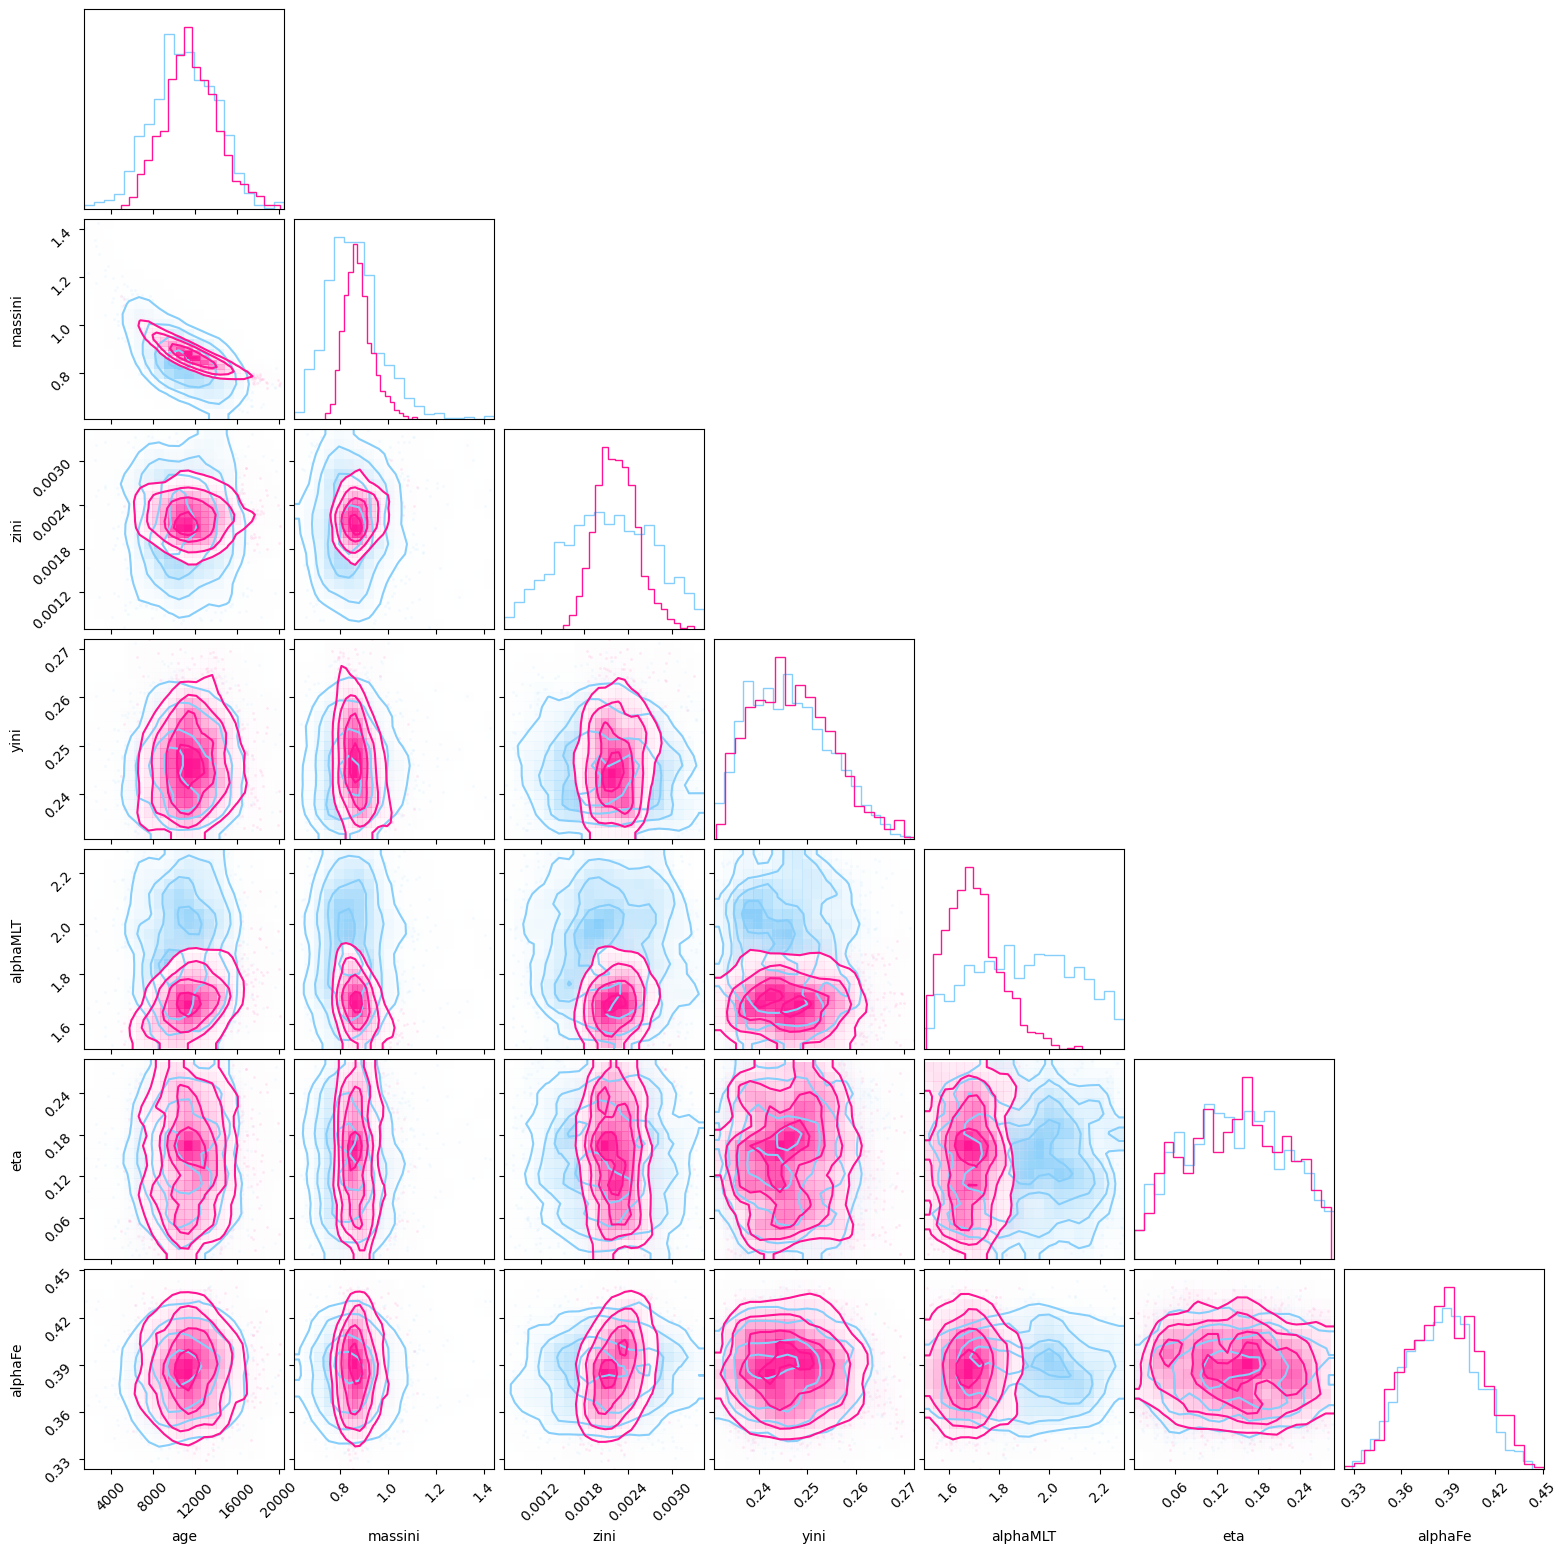

In [399]:
fig = corner.corner(data, group="prior", var_names = ['age', 'massini', 'zini', 'yini', 'alphaMLT', 'eta', 'alphaFe'],  color = 'lightskyblue', smooth = True, plot_datapoints = True,  weights = np.ones(num_prior_samples)/(num_prior_samples), coords = {'star':0})
corner.corner(data, group="posterior", var_names = ['age', 'massini', 'zini', 'yini', 'alphaMLT', 'eta', 'alphaFe'],  color = 'deeppink', zorder = 1,smooth = True, plot_datapoints = True,  weights = np.ones(num_chains*num_samples)/(num_chains*num_samples),fig = fig, coords = {'star':0})
plt.show()

In [361]:
len(pos_dict)

{'FeH': -1.07,
 'alphaFe': 0.39,
 'Teff': np.float64(4868.0),
 'numax': np.float64(61.963),
 'dnuSer': np.float64(6.873),
 'logLPhot': np.float64(1.3828451962962611),
 'LPhot': np.float64(24.146)}

In [39]:
ages = pos_dict['age'][0].T[0]

for i in range(1, len(pos_dict['age'])):   
    
    ages = np.concat((ages, pos_dict['age'][i].T[0]))
    

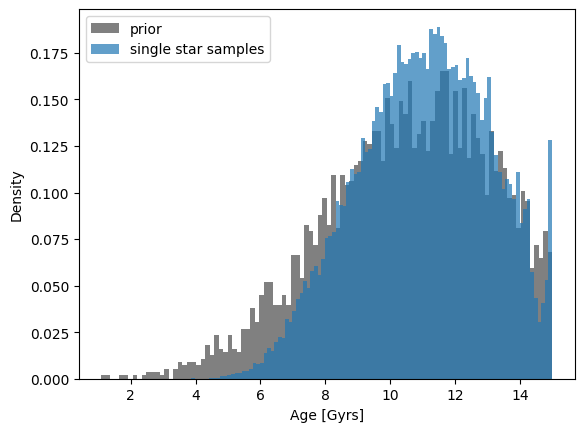

In [40]:
plt.hist(prior['age'].T[0]/10**3, density = True, bins = 100, color = 'grey', label = 'prior')
plt.hist(ages/10**3, bins = 100, density = True, alpha = 0.7, label = 'single star samples')
plt.legend()
plt.xlabel('Age [Gyrs]')
plt.ylabel('Density')
plt.savefig('../figs/single-star-inference-obs-FeH-obs-alphaFe-combined-age.png', bbox_inches = 'tight')

In [39]:
len(IDs_)

26

In [140]:
Y25

,star_id,evol_stage,Gaia_source_ID_DR3,2MASS_ID,Gmag,Quality_flag,numax_pyMon,numax_err_pyMon,Teff_final,Teff_err_final,Lum_bol,Lum_bol_err_random,Lum_bol_err_systematic,Mass,Mass_err_rand,Delta_nu,delta_nu_02,epsilon
3,M4RGB165,RGB,6.050000e+18,16230993-2628335,13.98,D,91.848136,2.085416,5287,108.001212,22.97,0.44,2.69,0.93,0.07,8.35,NaN,0.920
13,M4RGB188,RGB,6.050000e+18,16232169-2626468,13.04,D,30.981079,0.568750,4810,108.001212,44.00,1.53,5.11,0.84,0.07,3.75,NaN,0.600
15,M4RGB104,RGB,6.050000e+18,16232195-2630320,13.13,D,33.730326,0.568750,4851,108.001212,38.85,1.28,4.51,0.78,0.06,4.32,0.130,0.926
16,M4RGB17,RGB,6.050000e+18,16232252-2629422,13.54,D,51.888145,0.710937,4785,61.000000,28.35,0.60,3.29,0.92,0.05,5.84,0.170,1.230
22,M4RGB13,RGB,6.050000e+18,16232508-2629530,13.52,D,49.202833,1.990624,4840,108.001212,26.95,0.90,3.12,0.79,0.07,6.39,0.120,1.290
27,M4RGB229,RGB,6.050000e+18,16232982-2623253,12.49,D,15.949854,0.178361,4677,54.000000,73.89,1.62,8.58,0.80,0.04,2.66,0.190,0.920
32,M4RGB23,RGB,6.050000e+18,16233236-2629222,13.36,D,42.553491,1.042708,4897,108.001212,31.25,0.97,3.62,0.77,0.06,5.39,0.130,1.080
35,M4RGB37,RGB,6.050000e+18,16233380-2627497,13.14,D,35.136918,0.663541,4821,108.001212,39.61,1.35,4.60,0.85,0.07,4.86,0.170,0.890
36,M4RGB129,RGB,6.050000e+18,16233414-2630104,13.76,D,70.173835,1.990624,4989,108.001212,22.63,0.62,2.63,0.86,0.07,7.35,0.130,1.240
44,M4RGB252,RGB,6.050000e+18,16233768-2620381,13.57,D,55.276752,0.663541,5012,60.000000,26.65,0.41,3.09,0.78,0.04,5.84,0.130,1.050


In [153]:
obs

{'FeH': -1.1,
 'Teff': np.int64(4785),
 'numax': np.float64(51.88814456),
 'dnuSer': np.float64(5.84),
 'logLPhot': np.float64(1.4525530632289254)}